In [38]:

import os
import numpy as np
import flopy
import matplotlib.pyplot as plt
import pandas as pd

# Define the bed elevation for filtering particles
bed_elevation = 1599.8125  # Replace with the actual bed elevation value
ncol = 431
nrow = 385
#\Users\u4eeevmq\Documents\Python\HP_workspace
# Define the workspace and file names
workspace = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace"
workspace_gwf = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace"

model_name = "Hyporheic_Project_mp"  # Replace with your model name

#    r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_backward.mppth"
# Correct the simulation workspace path
model_ws = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace"

# Load the MODFLOW 6 simulation
sim = flopy.mf6.MFSimulation.load(sim_ws=workspace_gwf)
print(sim.model_names)

# Access the groundwater flow (GWF) model
gwf = sim.get_model("gwf_model")  # Replace "gwf_model" with your model name if different

# Get DIS package and idomain array
dis = gwf.get_package("DIS")

# Get model grid information
xorigin = dis.xorigin
yorigin = dis.yorigin
delr = dis.delr.array  # Column widths
delc = dis.delc.array  # Row heights

print(f"delr: {delr}")
print(f"delc: {delc}")

# Calculate spatial extents
x_min = xorigin.data  # Access the numerical value from MFScalar
x_max = xorigin.data + delr.sum()  # Access data and perform addition
y_min = yorigin.data  # Access the numerical value from MFScalar
y_max = yorigin.data + delc.sum()  # Access data and perform addition

extent = [x_min, x_max, y_min, y_max]
print(f"Spatial Extent: {extent}")

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package chd...
    loading package oc...
  loading solution package gwf_model...
['gwf_model']
delr: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.
 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5

✅ Loaded 1255 river cells from C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\river_cells.csv
River cells: [(0, 130, 267, 1600.7779541015625), (0, 131, 266, 1600.785888671875), (0, 131, 267, 1600.7843017578125), (0, 131, 268, 1600.78125), (0, 131, 269, 1600.7799072265625), (0, 131, 270, 1600.77783203125), (0, 132, 266, 1600.7908935546875), (0, 132, 267, 1600.7879638671875), (0, 132, 268, 1600.78369140625), (0, 132, 269, 1600.781982421875), (0, 132, 270, 1600.7791748046875), (0, 132, 271, 1600.7779541015625), (0, 132, 272, 1600.7760009765625), (0, 132, 273, 1600.7747802734375), (0, 132, 274, 1600.7735595703125), (0, 133, 265, 1600.81591796875), (0, 133, 266, 1600.8026123046875), (0, 133, 267, 1600.796875), (0, 133, 268, 1600.7894287109375), (0, 133, 269, 1600.78662109375), (0, 133, 270, 1600.7823486328125), (0, 133, 271, 1600.7803955078125), (0, 133, 272, 1600.7774658203125), (0, 133, 273, 1600.776123046875), (0, 133, 274, 1600.774169921875), (0, 133, 275, 1600.773193359375), (0, 133

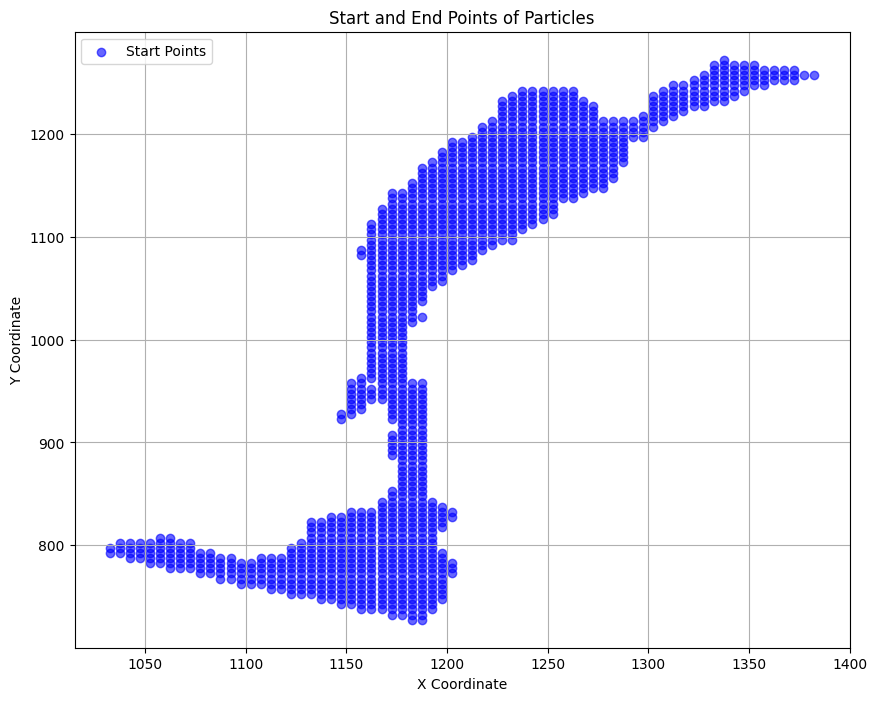

In [39]:
# Define the MODPATH 7 pathline and endpoint files
f_pathline_file = os.path.join(workspace, model_name + "_forward.mppth")
endpoint_file = os.path.join(workspace, model_name + "_forward.mpend")

# Load the river cells from the CSV file
river_cells_csv = "C:\\Users\\u4eeevmq\\Documents\\Python\\HyporheicFloPy\\river_cells.csv"  # Ensure the file path is correct

river_cells_df = pd.read_csv(river_cells_csv)

# Convert the DataFrame back to a list of tuples
river_cells = list(river_cells_df.itertuples(index=False, name=None))

print(f"✅ Loaded {len(river_cells)} river cells from {river_cells_csv}")

print(f"River cells: {river_cells}")

# Read endpoint data
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Extract numerical values from xorigin and yorigin
xorigin_value = xorigin.data  # Extract the numerical value
yorigin_value = yorigin.data  # Extract the numerical value

# Print the origin values for verification
print(f"xorigin: {xorigin_value}, yorigin: {yorigin_value}")
# Print the delr and delc arrays for verification
print(f"delr: {delr}, delc: {delc}")

# Convert river cell row/col indices to real-world coordinates
# Convert river cell row/col indices to real-world coordinates (cell centers)
river_cell_coords = [
    (
        sum(delr[:cell[2]]) + delr[cell[2]] / 2 + xorigin_value,  # X-coordinate (center)
        sum(delc[:cell[1]]) + delc[cell[1]] / 2 + yorigin_value   # Y-coordinate (center)
    )
    for cell in river_cells
]

# Convert to a set for quick lookup
river_cell_coords_set = set(river_cell_coords)


# Print a few converted coordinates for verification
print("Example converted river cell coordinates:", list(river_cell_coords_set)[:5])
print(f"delr: {delr}, delc: {delc}")

# Filter particles that end at or above the bed elevation and do not end in the same start cell
filtered_particles = [
    ep for ep in endpoints 
    if ep['z'] >= bed_elevation and (ep['x'], ep['y']) != (ep['x0'], ep['y0'])
]

# Filter particles that are within the river cells
# Initialize subsets
outliers = []
hyporheic_particles = []

# Filter particles into subsets
for ep in filtered_particles:
    particle_coords = (ep['x'], ep['y'])
    if particle_coords in river_cell_coords_set:
        hyporheic_particles.append(ep)  # Add to hyporheic particles
        print(f"Match found (Hyporheic): {particle_coords}")
    else:
        outliers.append(ep)  # Add to outliers
        print(f"No match (Outlier): {particle_coords}")

# Print summary
print(f"Total hyporheic particles: {len(hyporheic_particles)}")
print(f"Total outliers: {len(outliers)}")

# Get the particle IDs of filtered particles
filtered_particle_ids = [ep['particleid'] for ep in filtered_particles]

# Convert particle IDs to plain Python integers
filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]

print(f"Total particles ending at or above bed elevation: {len(filtered_particles)}")
print(f"Particle IDs ending at or above bed elevation: {filtered_particle_ids}")
print("Available fields in endpoint data:", endpoints[0].dtype.names)

# Convert filtered_particle_ids into a list
particle_ids_list = list(filtered_particle_ids)

# Print the resulting list
print(particle_ids_list)

# Plot results
# Define the workspace and file paths
model_name = "Hyporheic_Project_mp"
endpoint_file = os.path.join(workspace, model_name + "_forward.mpend")

# Read endpoint data
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Extract start and end points
start_points = [(ep['x0'], ep['y0'], ep['z0']) for ep in endpoints]  # Starting coordinates
end_points = [(ep['x'], ep['y'], ep['z']) for ep in endpoints]       # Ending coordinates

# Convert to NumPy arrays for easier manipulation
start_points = np.array(start_points)
end_points = np.array(end_points)

# Plot start and end points
plt.figure(figsize=(10, 8))
plt.scatter(start_points[:, 0], start_points[:, 1], c='blue', label='Start Points', alpha=0.6)
#plt.scatter(end_points[:, 0], end_points[:, 1], c='red', label='End Points', alpha=0.6)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Start and End Points of Particles')
plt.legend()
plt.grid(True)
plt.show()


Example residence times: [np.float32(783.1577), np.float32(65.29719), np.float32(618.54675), np.float32(198.52147), np.float32(762.71783)]


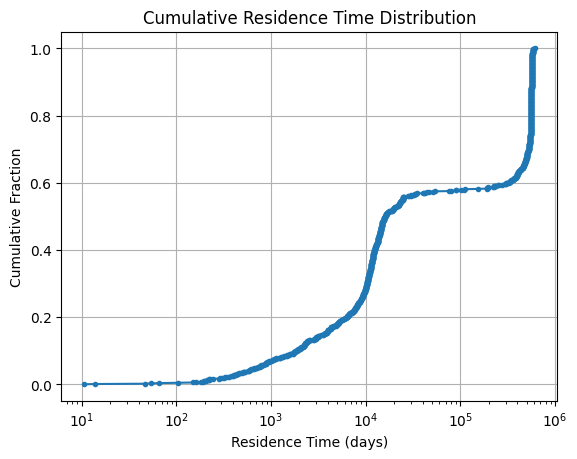

In [40]:
# Extract residence times (total travel time) for filtered particles
residence_times = [ep['time'] for ep in filtered_particles]

# Print a few to check
print("Example residence times:", residence_times[:5])

# Sort residence times
residence_times_sorted = np.sort(residence_times)

# Calculate cumulative fraction
cumulative_fraction = np.linspace(0, 1, len(residence_times_sorted)) # percent of particles

# Plot
plt.figure()
plt.plot(residence_times_sorted, cumulative_fraction, marker='.', linestyle='-')
plt.xscale('log')  # log scale on x-axis, like your figure
plt.xlabel('Residence Time (days)')
plt.ylabel('Cumulative Fraction')
plt.title('Cumulative Residence Time Distribution')
plt.grid(True)
plt.show()


Maximum residence time (minutes): 609750.12
Log Bins: [1.0561877e+01 3.5709751e+01 1.2073479e+02 4.0820468e+02 1.3801414e+03
 4.6662622e+03 1.5776665e+04 5.3340957e+04 1.8034594e+05 6.0975019e+05]


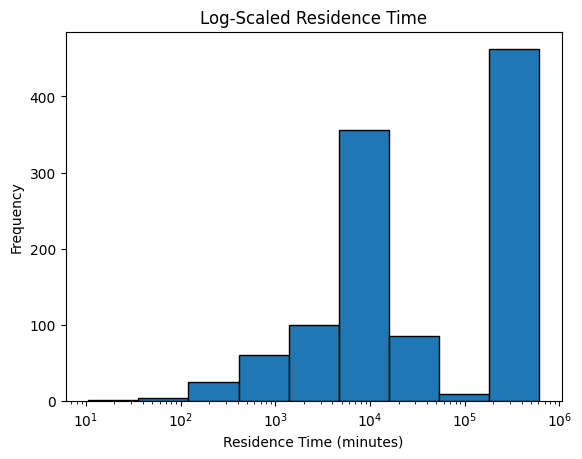

In [41]:
# Convert to minutes if needed (if your model uses days)
residence_times_min = np.array(residence_times) 
max_time = np.max(residence_times_min)
print(f"Maximum residence time (minutes): {max_time:.2f}")

# Plotting the histogram of residence times in Log-Bins
nonzero_times = residence_times_min[residence_times_min > 0]
if nonzero_times.size == 0:
    raise ValueError("No nonzero residence times to plot!")
min_time = np.min(nonzero_times)
num_bins = 10

bins = np.logspace(np.log10(min_time), np.log10(max_time), num_bins)
print("Log Bins:", bins)

plt.figure()
plt.hist(residence_times_min[residence_times_min > 0], bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Residence Time (minutes)')
plt.ylabel('Frequency')
plt.title('Log-Scaled Residence Time')
plt.show()


In [42]:
# Read pathline data only for selected partticles
pathline_reader = flopy.utils.PathlineFile(f_pathline_file)

# Load pathline data for all particle IDs in the list
filtered_pathlines = []
for particle_id in particle_ids_list:
    filtered_pathlines.extend(pathline_reader.get_data(partid=particle_id))

# Print the total number of pathlines and the particle IDs list
print(f"Total pathlines corresponding to filtered particles: {len(filtered_pathlines)}")
print("Particle IDs List:", particle_ids_list)

print(type(filtered_pathlines))


Total pathlines corresponding to filtered particles: 192194
Particle IDs List: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 2

In [43]:
# Plot MODPATH 7 output
import pandas as pd
print("Available fields in pathline data:", filtered_pathlines[0].dtype.names)

# Available fields in pathline data
column_names = [
    'particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time',
    'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep'
]

# Convert NumPy structured array to DataFrame and add column names
if isinstance(filtered_pathlines, list) and hasattr(filtered_pathlines[0], 'dtype'):
    filtered_pathlines_df = pd.DataFrame.from_records(filtered_pathlines, columns=column_names)

# Print the first few rows to check the structure
print(filtered_pathlines_df.head())

required_fields = ['x', 'y', 'z', 'time', 'k', 'particleid']
missing_fields = [field for field in required_fields if field not in filtered_pathlines_df.columns]
print("Missing fields:", missing_fields)



Available fields in pathline data: ('particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time', 'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep')
   particleid  particlegroup  sequencenumber  particleidloc  time  \
0           1              0               1              1  0.00   
1           1              0               1              1  0.01   
2           1              0               1              1  0.02   
3           1              0               1              1  0.03   
4           1              0               1              1  0.04   

             x            y            z  k   node      xloc      yloc  \
0  1332.500000  1267.500000  1600.312500  0  56727  0.500000  0.500000   
1  1332.500000  1267.481445  1600.316406  0  56727  0.500006  0.496275   
2  1332.500122  1267.462891  1600.320435  0  56727  0.500012  0.492579   
3  1332.500122  1267.444458  1600.324219  0  56727  0.500017  0.488910   
4  1332.500122  1267.4262

Spatial Extent: [2406093.51, np.float64(2408248.51), 10514475.4, np.float64(10516400.4)]


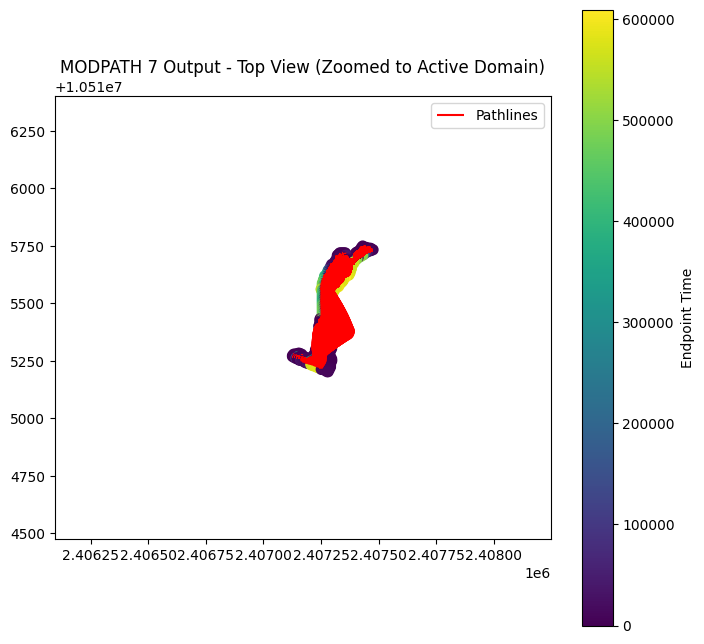

In [44]:

# Calculate spatial extents
x_min = xorigin.data  # Access the numerical value from MFScalar
x_max = xorigin.data + delr.sum()  # Access data and perform addition
y_min = yorigin.data  # Access the numerical value from MFScalar
y_max = yorigin.data + delc.sum()  # Access data and perform addition

extent = [x_min, x_max, y_min, y_max]
print(f"Spatial Extent: {extent}")

# Plot top view
plt.figure(figsize=(8, 8))
mm = flopy.plot.PlotMapView(model=gwf)

# Plot grid (optional, set lw=0 to hide grid lines)
mm.plot_grid(lw=0)

# Plot pathlines
mm.plot_pathline(filtered_pathlines_df, layer="all", colors="red", label="Pathlines")

# Plot endpoints (if available)
mm.plot_endpoint(endpoints, direction="starting", colorbar=True)

# Apply spatial extent for zooming
mm.ax.set_xlim(extent[0], extent[1])
mm.ax.set_ylim(extent[2], extent[3])

# Add title and legend
plt.title("MODPATH 7 Output - Top View (Zoomed to Active Domain)")
mm.ax.legend()
plt.show()

# NOTE: If the model domain does not fully encompass the flow system, particles may terminate at the edges because the domain does not capture the entire flow field.

In [ ]:
# Access DIS package to get model grid information
botm = dis.botm.array  # Bottom elevations of layers
nlay, nrow, ncol = botm.shape  # Number of layers, rows, and columns

print(filtered_pathlines_df[:5])  # Display the first 5 elements

# Create x-coordinates for the grid
x_coords = xorigin.data + np.cumsum(delr) - (delr / 2)  # Center of each column in the x-direction

# Plot side view
plt.figure(figsize=(10, 6))

# Plot grid layers (botm)
for layer in range(nlay):
    plt.plot(
        x_coords, botm[layer, 0, :],
        color="black", lw=0.5,
    )

# Plot pathlines in the side view using column indices
for i, pathline in filtered_pathlines_df.iterrows():  # Assuming it's a Pandas DataFrame
    plt.plot(
        pathline.iloc[5],  # x-coordinate (column index 5)
        pathline.iloc[8],  # z-coordinate (column index 8)
        color="red", lw=0.5, alpha=0.7,
        label="Pathlines" if i == 0 else ""  # Add label only for the first pathline
    )


# Add labels and legend
plt.xlabel("X Coordinate (East-West Direction)")
plt.ylabel("Z Coordinate (Elevation)")
plt.title("MODPATH 7 Output - Side View (Cross Section)")
plt.legend()
plt.grid(True)

plt.show()

   particleid  particlegroup  sequencenumber  particleidloc  time  \
0           1              0               1              1  0.00   
1           1              0               1              1  0.01   
2           1              0               1              1  0.02   
3           1              0               1              1  0.03   
4           1              0               1              1  0.04   

             x            y            z  k   node      xloc      yloc  \
0  1332.500000  1267.500000  1600.312500  0  56727  0.500000  0.500000   
1  1332.500000  1267.481445  1600.316406  0  56727  0.500006  0.496275   
2  1332.500122  1267.462891  1600.320435  0  56727  0.500012  0.492579   
3  1332.500122  1267.444458  1600.324219  0  56727  0.500017  0.488910   
4  1332.500122  1267.426270  1600.328125  0  56727  0.500023  0.485269   

       zloc  stressperiod  timestep  
0  0.500000             1         1  
1  0.503945             1         1  
2  0.507860             1 

In [ ]:
import alphashape
from shapely.geometry import Polygon

# Extract unique (x, y, z) coordinates
coordinates = filtered_pathlines_df[['x', 'y', 'z']].drop_duplicates()

print("Number of unique pathline points:", len(coordinates))

from scipy.spatial import ConvexHull
import numpy as np

# Group pathline data by 'particleid'
grouped_pathlines = filtered_pathlines_df.groupby('particleid')

# Initialize 2D plot
plt.figure(figsize=(10, 8))

# Plot pathlines as lines
for particle_id, group in grouped_pathlines:
    # Sort the group by 'time' or 'sequencenumber' to ensure correct line ordering
    group = group.sort_values(by='time')  # or 'sequencenumber'

    # Extract x, y coordinates
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()

    # Plot the line for this particle
    plt.plot(x, y, label=f"Particle {particle_id}" if particle_id < 5 else "")  # Label only first few particles for clarity

# Convert coordinates to NumPy array for Alpha Shape
coordinates = filtered_pathlines_df[['x', 'y']].drop_duplicates()
points_2d = coordinates.to_numpy()

# Compute the alpha shape (concave hull)
# Try a range of alpha values for your data; lower alpha = more detail, higher = more convex
alpha = 30  # You may need to adjust this value based on your data scale and density
concave_hull = alphashape.alphashape(points_2d, alpha)

# Get the area
if isinstance(concave_hull, Polygon):
    area = concave_hull.area
    # Plot the alpha shape polygon
    xh, yh = concave_hull.exterior.xy
    plt.plot(xh, yh, 'm-', lw=2, label=f"Alpha Shape (area={area:.1f})")
else:
    area = float('nan')
    print("Alpha shape did not produce a polygon. Try adjusting alpha.")

# Add labels, title, and legend
plt.title("2D Pathlines as Lines with Alpha Shape")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc='upper right', fontsize='small', ncol=1)
plt.show()

print(f"Alpha shape area: {area:.2f}")


ModuleNotFoundError: No module named 'alphashape'

Volume covered by pathlines (3D): 822369.6149431766


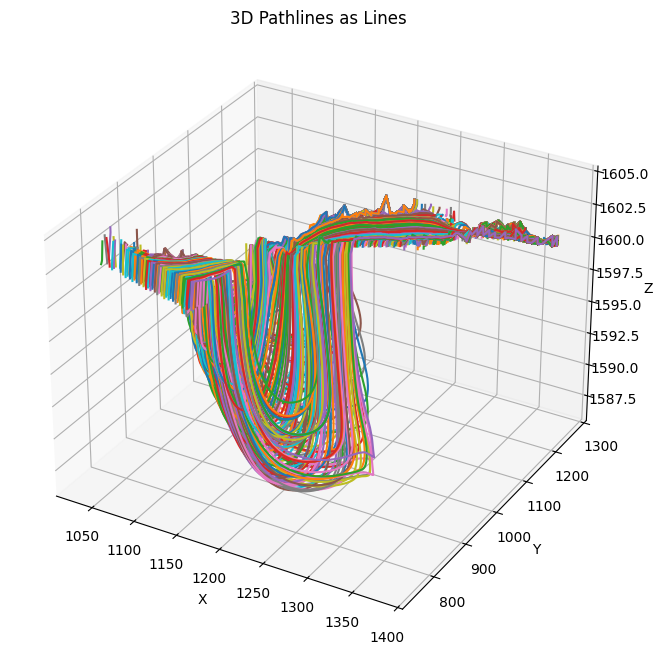

In [ ]:
# Convert coordinates to NumPy array (3D)
coordinates = filtered_pathlines_df[['x', 'y', 'z']].drop_duplicates()

points_3d = coordinates[['x', 'y', 'z']].to_numpy()

# Calculate Convex Hull
hull_3d = ConvexHull(points_3d)

# Volume of the convex hull
print("Volume covered by pathlines (3D):", hull_3d.volume)

from mpl_toolkits.mplot3d import Axes3D

# Group pathline data by 'particleid'
grouped_pathlines = filtered_pathlines_df.groupby('particleid')

# Initialize 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot pathlines as lines
for particle_id, group in grouped_pathlines:
    # Sort the group by 'time' or 'sequencenumber' to ensure correct line ordering
    group = group.sort_values(by='time')  # or 'sequencenumber'

    # Extract x, y, z coordinates
    x = group['x'].to_numpy()
    y = group['y'].to_numpy()
    z = group['z'].to_numpy()

    # Plot the line for this particle
    ax.plot(x, y, z, label=f"Particle {particle_id}" if particle_id < 5 else "")  # Label only first few particles for clarity

# Add labels, title, and legend
ax.set_title("3D Pathlines as Lines")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

Filtered pathlines: 192194 remaining


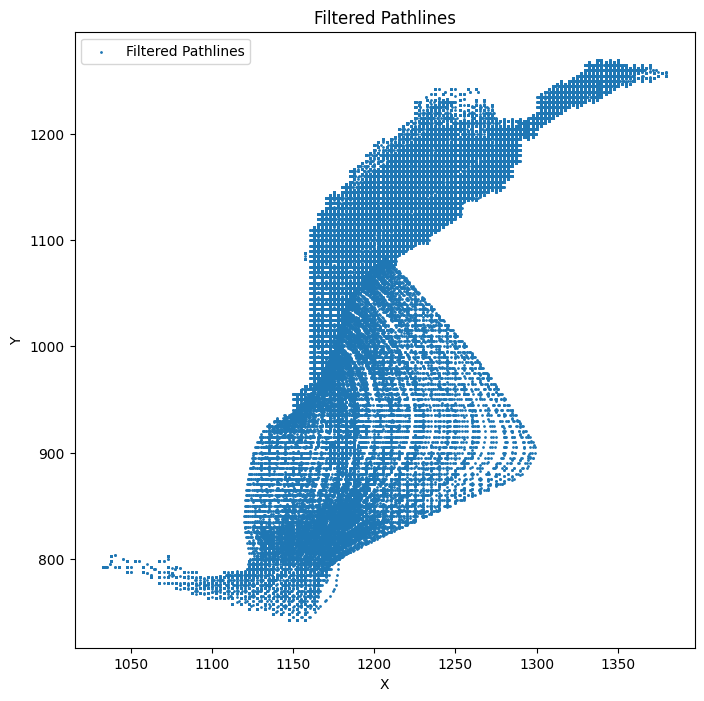

In [ ]:
# Removing Edge Effects
# Filter pathlines that are within the convex hull
# Extract x, y coordinates
points_2d = filtered_pathlines_df[['x', 'y']].to_numpy()

# Calculate Convex Hull
hull = ConvexHull(points_2d)

# Function to check if a point is inside the convex hull
def is_inside_hull(point, hull):
    from scipy.spatial import Delaunay
    return Delaunay(hull.points[hull.vertices]).find_simplex(point) >= 0

# Filter points inside the convex hull
filtered_pathlines_df['inside_hull'] = filtered_pathlines_df.apply(
    lambda row: is_inside_hull([row['x'], row['y']], hull), axis=1
)

filtered_pathlines_df = filtered_pathlines_df[filtered_pathlines_df['inside_hull']]
print(f"Filtered pathlines: {len(filtered_pathlines_df)} remaining")

# Re-plot filtered pathlines
plt.figure(figsize=(8, 8))
plt.scatter(filtered_pathlines_df['x'], filtered_pathlines_df['y'], s=1, label="Filtered Pathlines")
plt.title("Filtered Pathlines")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

# Extract x, y coordinates of the pathlines
xy_coords = filtered_pathlines_df[['x', 'y']].to_numpy()

# Perform Kernel Density Estimation (KDE)
kde = KernelDensity(kernel='gaussian', bandwidth=10).fit(xy_coords)  # Adjust bandwidth based on your model scale
density = kde.score_samples(xy_coords)

# Add density as a column in the DataFrame
filtered_pathlines_df['density'] = density

# Define a density threshold (e.g., keep only high-density points)
density_threshold = np.percentile(density, 80)  # Keep the top 20% of points by density
high_density_pathlines = filtered_pathlines_df[filtered_pathlines_df['density'] >= density_threshold]

print(f"Number of high-density pathline points: {len(high_density_pathlines)}")
plt.figure(figsize=(8, 8))
plt.scatter(filtered_pathlines_df['x'], filtered_pathlines_df['y'], s=1, alpha=0.3, label='All Pathlines')
plt.scatter(high_density_pathlines['x'], high_density_pathlines['y'], s=1, color='red', label='High-Density Pathlines')
plt.title("High-Density Pathlines (2D)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'sklearn'